In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, Model

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
from google.colab import files

uploaded = files.upload()

Saving AGB_EO_SENTINEL.csv to AGB_EO_SENTINEL.csv


In [4]:
file_path = "AGB_EO_SENTINEL.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Shape: (8774, 24)


,dataset,plot_id,start_date,end_date,latitude_x,longitude_x,diameter,height,species,plant_AGB_kg,...,Green,Red,NIR,SWIR1,SWIR2,NDVI,MNDWI,NBR,EVI,CLOUD_COVERAGE
0,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,26.3,12.0,mangle,630.627596,...,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
1,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,28.6,14.0,mangle,784.223246,...,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
2,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,19.2,4.0,mangle,139.136548,...,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
3,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,6.2,8.0,mangle,14.726733,...,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
4,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,5.2,5.0,mangle,9.321734,...,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0


['dataset', 'plot_id', 'start_date', 'end_date', 'latitude_x', 'longitude_x', 'diameter', 'height', 'species', 'plant_AGB_kg', 'longitude_y', 'latitude_y', 'time', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE']


In [5]:
# EO-only satellite features
eo_cols = [
    "Blue", "Green", "Red", "NIR",
    "SWIR1", "SWIR2",
    "NDVI", "MNDWI", "NBR", "EVI",
    "CLOUD_COVERAGE"
]

target_col = "plant_AGB_kg"

# Keep only satellite features, target, and plot_id for grouped splitting
model_df = df[["plot_id"] + eo_cols + [target_col]].copy()

# Remove missing satellite/target rows
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=eo_cols + [target_col])

# Log-transform target
model_df["AGB_log"] = np.log1p(model_df[target_col])

print("Original shape:", df.shape)
print("Model shape after cleaning:", model_df.shape)
print("Unique plots:", model_df["plot_id"].nunique())
display(model_df.head())

Original shape: (8774, 24)
Model shape after cleaning: (8160, 14)
Unique plots: 291


,plot_id,Blue,Green,Red,NIR,SWIR1,SWIR2,NDVI,MNDWI,NBR,EVI,CLOUD_COVERAGE,plant_AGB_kg,AGB_log
0,El_Jobal_9_6,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0,630.627596,6.448300
1,El_Jobal_9_6,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0,784.223246,6.665968
2,El_Jobal_9_6,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0,139.136548,4.942617
3,El_Jobal_9_6,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0,14.726733,2.755362
4,El_Jobal_9_6,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0,9.321734,2.334252


In [6]:
# Split by unique plot IDs (not rows)
plot_ids = model_df["plot_id"].unique()

train_plots, temp_plots = train_test_split(
    plot_ids,
    test_size=0.30,
    random_state=42
)

val_plots, test_plots = train_test_split(
    temp_plots,
    test_size=0.50,
    random_state=42
)

# Masks
train_idx = model_df["plot_id"].isin(train_plots)
val_idx   = model_df["plot_id"].isin(val_plots)
test_idx  = model_df["plot_id"].isin(test_plots)

# Features and target
X = model_df[eo_cols].values
y = model_df["AGB_log"].values

# Split arrays
X_train = X[train_idx]
X_val   = X[val_idx]
X_test  = X[test_idx]

y_train = y[train_idx]
y_val   = y[val_idx]
y_test  = y[test_idx]

print("Train rows:", X_train.shape)
print("Val rows:", X_val.shape)
print("Test rows:", X_test.shape)

print("Train plots:", len(train_plots))
print("Val plots:", len(val_plots))
print("Test plots:", len(test_plots))

Train rows: (6006, 11)
Val rows: (1066, 11)
Test rows: (1088, 11)
Train plots: 203
Val plots: 44
Test plots: 44


In [7]:
# Scale EO features using training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("Any NaNs in train?", np.isnan(X_train_scaled).sum())
print("Any NaNs in val?", np.isnan(X_val_scaled).sum())
print("Any NaNs in test?", np.isnan(X_test_scaled).sum())

X_train_scaled shape: (6006, 11)
X_val_scaled shape: (1066, 11)
X_test_scaled shape: (1088, 11)
Any NaNs in train? 0
Any NaNs in val? 0
Any NaNs in test? 0


In [8]:
# Build EO-only neural network

eo_input = layers.Input(shape=(X_train_scaled.shape[1],), name="eo_input")

x = layers.Dense(64, activation="relu")(eo_input)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)

output = layers.Dense(1, activation="linear")(x)

eo_model = Model(inputs=eo_input, outputs=output)

eo_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

eo_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eo_input (InputLayer)           │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_eo = eo_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=5,
            factor=0.3
        )
    ],
    verbose=1
)

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.9197 - mae: 1.3243 - val_loss: 0.9680 - val_mae: 1.4063 - learning_rate: 0.0010
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6184 - mae: 0.9872 - val_loss: 1.0298 - val_mae: 1.4750 - learning_rate: 0.0010
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5670 - mae: 0.9251 - val_loss: 0.9726 - val_mae: 1.4122 - learning_rate: 0.0010
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5333 - mae: 0.8813 - val_loss: 0.9568 - val_mae: 1.3953 - learning_rate: 0.0010
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5138 - mae: 0.8581 - val_loss: 0.9372 - val_mae: 1.3689 - learning_rate: 0.0010
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4981 - mae: 0.8390 - val_loss: 0.9103 - val_mae: 1.3348 - learning_rate: 0.0010
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4831 - mae: 0.8215 - val_loss: 0.8986 - val_mae: 1.3356 - learning_rate: 0.001

In [10]:
# Predict on test set
y_pred_log = eo_model.predict(X_test_scaled).ravel()

# Convert log predictions back to real AGB kg
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("EO-only Model Test Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   
EO-only Model Test Results
RMSE: 488.63881366818566
MAE: 90.7939309234599
R2: -0.019837956704798376


Median AGB: 19.4489276656436
95th percentile: 314.92093769619123
99th percentile: 1844.411762840932
Max AGB: 11337.300328982989


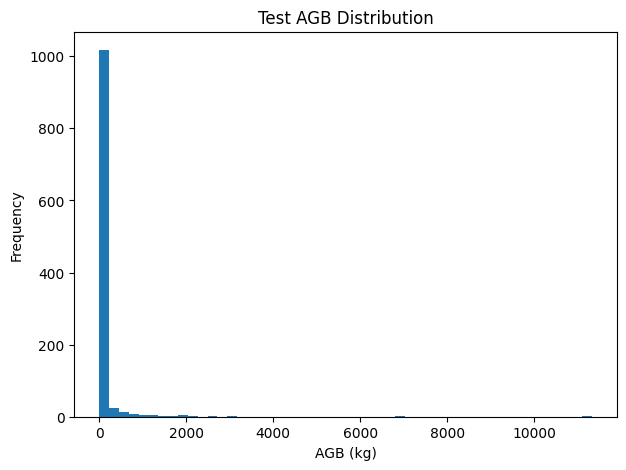

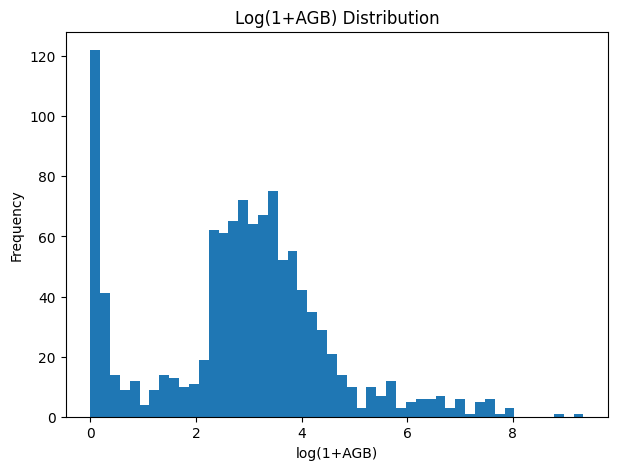

In [11]:
# Basic AGB distribution diagnostics

print("Median AGB:", np.median(y_test_real))
print("95th percentile:", np.percentile(y_test_real,95))
print("99th percentile:", np.percentile(y_test_real,99))
print("Max AGB:", np.max(y_test_real))

# Histogram
plt.figure(figsize=(7,5))
plt.hist(y_test_real, bins=50)
plt.title("Test AGB Distribution")
plt.xlabel("AGB (kg)")
plt.ylabel("Frequency")
plt.show()

# Log-scale histogram
plt.figure(figsize=(7,5))
plt.hist(np.log1p(y_test_real), bins=50)
plt.title("Log(1+AGB) Distribution")
plt.xlabel("log(1+AGB)")
plt.ylabel("Frequency")
plt.show()

In [12]:
# Evaluate model excluding top 5% biggest trees

threshold95 = np.percentile(y_test_real, 95)

mask95 = y_test_real <= threshold95

rmse95 = np.sqrt(
    mean_squared_error(
        y_test_real[mask95],
        y_pred_real[mask95]
    )
)

mae95 = mean_absolute_error(
    y_test_real[mask95],
    y_pred_real[mask95]
)

r2_95 = r2_score(
    y_test_real[mask95],
    y_pred_real[mask95]
)

print("Performance excluding top 5% AGB")
print("Threshold:", threshold95)
print("RMSE:", rmse95)
print("MAE:", mae95)
print("R2:", r2_95)

Performance excluding top 5% AGB
Threshold: 314.92093769619123
RMSE: 48.61592456551586
MAE: 24.698657400748207
R2: -0.10443525617519489


In [13]:
# Count trees per plot
plot_counts = model_df.groupby("plot_id").size()

print("Median trees per plot:", plot_counts.median())
print("Max trees per plot:", plot_counts.max())

# AGB variability within plots
agb_var = model_df.groupby("plot_id")["plant_AGB_kg"].agg(
    ["count","mean","std","min","max"]
)

print(agb_var.sort_values("std", ascending=False).head(10))

Median trees per plot: 16.0
Max trees per plot: 120
                         count         mean          std        min  \
plot_id                                                               
Montecristo_22_2             7  1481.204145  3592.051067  27.651485   
Montecristo_22_3            12  1179.613146  3229.707929  10.785270   
El_Plan_de_la_Ceiba_8_6      6  1862.424227  2801.887257   8.418022   
Montecristo_21_3             6  1059.541331  2311.525423   8.418022   
Montecristo_21_2             5  1110.599354  2034.631706  12.945036   
El_Plan_de_la_Ceiba_8_1     12  1008.762493  1949.096625   0.056562   
Montecristo_22_4             6  1218.892089  1521.550848   0.031103   
El_Plan_de_la_Ceiba_8_3      5   748.620079  1488.181085  18.724542   
Samuria_19_2                22   363.220197  1464.858133   0.022262   
CAE_Caetano                 88   510.792600  1351.764346   0.050716   

                                  max  
plot_id                                
Montecristo_22_

In [14]:
# Aggregate to plot-level

plot_df = model_df.groupby("plot_id").agg({
    "Blue":"mean",
    "Green":"mean",
    "Red":"mean",
    "NIR":"mean",
    "SWIR1":"mean",
    "SWIR2":"mean",
    "NDVI":"mean",
    "MNDWI":"mean",
    "NBR":"mean",
    "EVI":"mean",
    "CLOUD_COVERAGE":"mean",

    # target: total plot biomass
    "plant_AGB_kg":"sum"
}).reset_index()

plot_df["AGB_log"] = np.log1p(plot_df["plant_AGB_kg"])

print("Plot-level shape:", plot_df.shape)
print("Unique plots:", plot_df["plot_id"].nunique())

display(plot_df.head())

Plot-level shape: (291, 14)
Unique plots: 291


,plot_id,Blue,Green,Red,NIR,SWIR1,SWIR2,NDVI,MNDWI,NBR,EVI,CLOUD_COVERAGE,plant_AGB_kg,AGB_log
0,ACA_Acarau Boca,0.011147,0.029933,0.014972,0.244315,0.064928,0.022117,0.884195,-0.368995,0.833881,0.458323,1.0,17050.315166,9.743983
1,Arco_del_Espino_18_1,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,7168.576410,8.877602
2,Arco_del_Espino_18_2,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,2670.565468,7.890420
3,Arco_del_Espino_18_3,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,7600.502092,8.936101
4,Arco_del_Espino_18_4,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,2796.862629,7.936611


In [15]:
# Plot-level features and target
X_plot = plot_df[eo_cols].values
y_plot = plot_df["AGB_log"].values

# Split rows (each row is already one plot)
X_train_p, X_temp_p, y_train_p, y_temp_p = train_test_split(
    X_plot,
    y_plot,
    test_size=0.30,
    random_state=42
)

X_val_p, X_test_p, y_val_p, y_test_p = train_test_split(
    X_temp_p,
    y_temp_p,
    test_size=0.50,
    random_state=42
)

# Scale
scaler_plot = StandardScaler()

X_train_p = scaler_plot.fit_transform(X_train_p)
X_val_p   = scaler_plot.transform(X_val_p)
X_test_p  = scaler_plot.transform(X_test_p)

print("Train:", X_train_p.shape)
print("Val:", X_val_p.shape)
print("Test:", X_test_p.shape)

Train: (203, 11)
Val: (44, 11)
Test: (44, 11)


In [16]:
# Plot-level EO model

eo_input = layers.Input(shape=(11,))

x = layers.Dense(64, activation="relu")(eo_input)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)

output = layers.Dense(1)(x)

plot_model = Model(inputs=eo_input, outputs=output)

plot_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

history_plot = plot_model.fit(
    X_train_p,
    y_train_p,
    validation_data=(X_val_p, y_val_p),
    epochs=100,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=10,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            patience=5,
            factor=0.3
        )
    ],
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - loss: 5.2510 - mae: 5.7405 - val_loss: 4.8671 - val_mae: 5.3623 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.6073 - mae: 5.0960 - val_loss: 3.9814 - val_mae: 4.4814 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.6921 - mae: 4.1813 - val_loss: 2.9335 - val_mae: 3.4082 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.8480 - mae: 3.3246 - val_loss: 2.1077 - val_mae: 2.5606 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1123 - mae: 2.5907 - val_loss: 1.4664 - val_mae: 1.9093 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.7629 - mae: 2.2205 - val_loss: 1.0903 - val_mae: 1.5612 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.5366 - mae: 1.9863 - val_loss: 0.9693 - val_mae: 1.4004 - learning_rate: 0.0010
Epoch 8/100

In [17]:
# Predict
y_pred_log_p = plot_model.predict(X_test_p).ravel()

# Back-transform
y_pred_p = np.expm1(y_pred_log_p)
y_test_p_real = np.expm1(y_test_p)

# Metrics
rmse_p = np.sqrt(mean_squared_error(y_test_p_real, y_pred_p))
mae_p = mean_absolute_error(y_test_p_real, y_pred_p)
r2_p = r2_score(y_test_p_real, y_pred_p)

print("Plot-level EO Model Results")
print("RMSE:", rmse_p)
print("MAE:", mae_p)
print("R2:", r2_p)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 411ms/step
Plot-level EO Model Results
RMSE: 5542.6614459879775
MAE: 1642.3707951797892
R2: 0.310045091925671


Plot-level AGB summary:
count      291.000000
mean      1863.306230
std       4120.805952
min          0.049787
25%        140.621311
50%        620.492147
75%       2024.987310
max      44949.748775
Name: plant_AGB_kg, dtype: float64

Percentiles:
50th percentile: 620.4921467733966
75th percentile: 2024.98731
90th percentile: 4391.916524727774
95th percentile: 6795.536296374397
99th percentile: 20127.910912257827


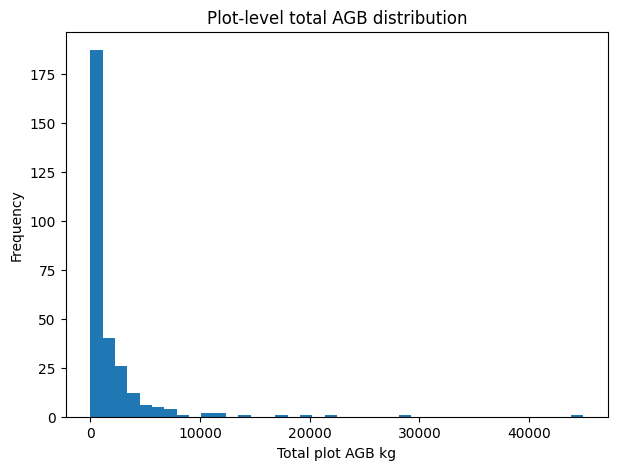

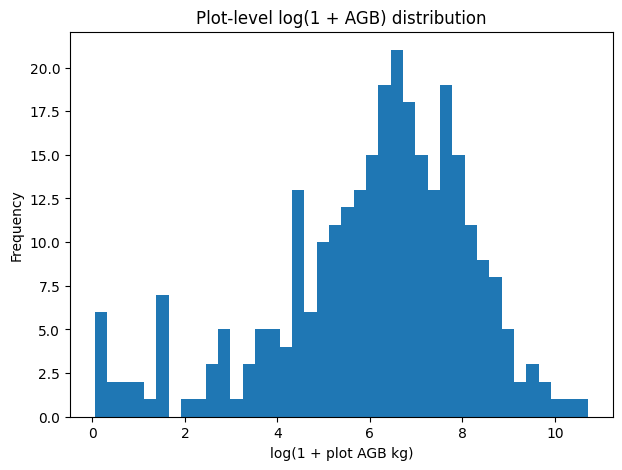

In [18]:
print("Plot-level AGB summary:")
print(plot_df["plant_AGB_kg"].describe())

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(plot_df["plant_AGB_kg"], p))

plt.figure(figsize=(7,5))
plt.hist(plot_df["plant_AGB_kg"], bins=40)
plt.title("Plot-level total AGB distribution")
plt.xlabel("Total plot AGB kg")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,5))
plt.hist(plot_df["AGB_log"], bins=40)
plt.title("Plot-level log(1 + AGB) distribution")
plt.xlabel("log(1 + plot AGB kg)")
plt.ylabel("Frequency")
plt.show()

In [19]:
# Rebuild plot-level dataset using MEAN AGB instead of SUM

plot_df_mean = model_df.groupby("plot_id").agg({
    "Blue":"mean",
    "Green":"mean",
    "Red":"mean",
    "NIR":"mean",
    "SWIR1":"mean",
    "SWIR2":"mean",
    "NDVI":"mean",
    "MNDWI":"mean",
    "NBR":"mean",
    "EVI":"mean",
    "CLOUD_COVERAGE":"mean",

    # new target
    "plant_AGB_kg":"mean"
}).reset_index()

plot_df_mean["AGB_log"] = np.log1p(plot_df_mean["plant_AGB_kg"])

print(plot_df_mean["plant_AGB_kg"].describe())
display(plot_df_mean.head())

count     291.000000
mean      140.906301
std       257.905013
min         0.004448
25%        13.041081
50%        45.949646
75%       145.448984
max      1862.424227
Name: plant_AGB_kg, dtype: float64


,plot_id,Blue,Green,Red,NIR,SWIR1,SWIR2,NDVI,MNDWI,NBR,EVI,CLOUD_COVERAGE,plant_AGB_kg,AGB_log
0,ACA_Acarau Boca,0.011147,0.029933,0.014972,0.244315,0.064928,0.022117,0.884195,-0.368995,0.833881,0.458323,1.0,284.171919,5.653092
1,Arco_del_Espino_18_1,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,551.428955,6.314325
2,Arco_del_Espino_18_2,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,381.509353,5.946753
3,Arco_del_Espino_18_3,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,584.654007,6.372729
4,Arco_del_Espino_18_4,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,466.143772,6.146637


In [20]:
# Features and target
X_mean = plot_df_mean[eo_cols].values
y_mean = plot_df_mean["AGB_log"].values

# Split
X_train_m, X_temp_m, y_train_m, y_temp_m = train_test_split(
    X_mean, y_mean,
    test_size=0.30,
    random_state=42
)

X_val_m, X_test_m, y_val_m, y_test_m = train_test_split(
    X_temp_m, y_temp_m,
    test_size=0.50,
    random_state=42
)

# Scale
scaler_m = StandardScaler()

X_train_m = scaler_m.fit_transform(X_train_m)
X_val_m   = scaler_m.transform(X_val_m)
X_test_m  = scaler_m.transform(X_test_m)

print(X_train_m.shape)
print(X_val_m.shape)
print(X_test_m.shape)

(203, 11)
(44, 11)
(44, 11)


In [21]:
# Same architecture, fresh model

eo_input = layers.Input(shape=(11,))

x = layers.Dense(64, activation="relu")(eo_input)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)

output = layers.Dense(1)(x)

mean_model = Model(inputs=eo_input, outputs=output)

mean_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

history_mean = mean_model.fit(
    X_train_m,
    y_train_m,
    validation_data=(X_val_m, y_val_m),
    epochs=100,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=10,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            patience=5,
            factor=0.3
        )
    ],
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - loss: 3.1235 - mae: 3.5909 - val_loss: 3.1015 - val_mae: 3.5787 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.7951 - mae: 3.2707 - val_loss: 2.7339 - val_mae: 3.2249 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.4147 - mae: 2.8919 - val_loss: 2.2616 - val_mae: 2.7437 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9517 - mae: 2.4230 - val_loss: 1.7122 - val_mae: 2.1792 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5162 - mae: 1.9641 - val_loss: 1.2367 - val_mae: 1.6723 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2152 - mae: 1.6656 - val_loss: 1.0531 - val_mae: 1.4929 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0974 - mae: 1.5229 - val_loss: 0.9915 - val_mae: 1.4342 - learning_rate: 0.0010
Epoch 8/100

In [22]:
# Predict
y_pred_log_m = mean_model.predict(X_test_m).ravel()

# Back-transform
y_pred_m = np.expm1(y_pred_log_m)
y_test_m_real = np.expm1(y_test_m)

# Metrics
rmse_m = np.sqrt(mean_squared_error(y_test_m_real, y_pred_m))
mae_m = mean_absolute_error(y_test_m_real, y_pred_m)
r2_m = r2_score(y_test_m_real, y_pred_m)

print("Plot-level Mean AGB EO Model Results")
print("RMSE:", rmse_m)
print("MAE:", mae_m)
print("R2:", r2_m)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 403ms/step
Plot-level Mean AGB EO Model Results
RMSE: 129.62095588558861
MAE: 61.358051090692975
R2: 0.20292500256292434


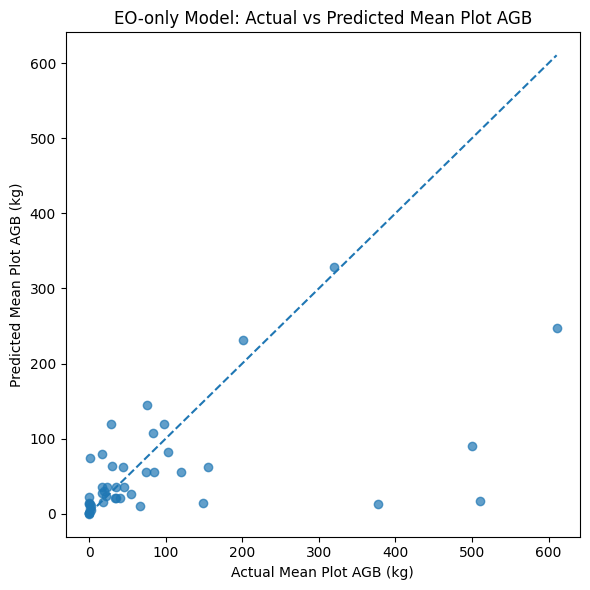

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_m_real, y_pred_m, alpha=0.7)

plt.plot(
    [y_test_m_real.min(), y_test_m_real.max()],
    [y_test_m_real.min(), y_test_m_real.max()],
    linestyle="--"
)

plt.xlabel("Actual Mean Plot AGB (kg)")
plt.ylabel("Predicted Mean Plot AGB (kg)")
plt.title("EO-only Model: Actual vs Predicted Mean Plot AGB")
plt.tight_layout()
plt.show()

In [24]:
coords_cols = ["latitude_x","longitude_x"]

print(df[coords_cols].describe())

        latitude_x  longitude_x
count  8774.000000  8774.000000
mean     13.751943   -84.770866
std       4.887172    11.440609
min      -2.850264   -88.955557
25%      13.257775   -88.655700
50%      15.801897   -88.328149
75%      16.644709   -87.812320
max      18.342280   -40.031187


In [25]:
# Add spatial coordinates (not leakage)
eo_coord_cols = eo_cols + ["latitude_x","longitude_x"]

print(eo_coord_cols)
print("Feature count:", len(eo_coord_cols))

['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE', 'latitude_x', 'longitude_x']
Feature count: 13


In [26]:
# Rebuild plot-level dataset including coordinates

plot_df_coord = model_df.groupby("plot_id").agg({
    "Blue":"mean",
    "Green":"mean",
    "Red":"mean",
    "NIR":"mean",
    "SWIR1":"mean",
    "SWIR2":"mean",
    "NDVI":"mean",
    "MNDWI":"mean",
    "NBR":"mean",
    "EVI":"mean",
    "CLOUD_COVERAGE":"mean",

    "plant_AGB_kg":"mean"
}).reset_index()

# Add plot-level coordinates from original df
coords_plot = (
    df.groupby("plot_id")[["latitude_x","longitude_x"]]
    .mean()
    .reset_index()
)

plot_df_coord = plot_df_coord.merge(
    coords_plot,
    on="plot_id",
    how="left"
)

plot_df_coord["AGB_log"] = np.log1p(plot_df_coord["plant_AGB_kg"])

print(plot_df_coord.shape)
display(plot_df_coord.head())

(291, 16)


,plot_id,Blue,Green,Red,NIR,SWIR1,SWIR2,NDVI,MNDWI,NBR,EVI,CLOUD_COVERAGE,plant_AGB_kg,latitude_x,longitude_x,AGB_log
0,ACA_Acarau Boca,0.011147,0.029933,0.014972,0.244315,0.064928,0.022117,0.884195,-0.368995,0.833881,0.458323,1.0,284.171919,-2.843732,-40.133709,5.653092
1,Arco_del_Espino_18_1,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,551.428955,13.187182,-88.329576,6.314325
2,Arco_del_Espino_18_2,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,381.509353,13.187182,-88.329576,5.946753
3,Arco_del_Espino_18_3,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,584.654007,13.187182,-88.329576,6.372729
4,Arco_del_Espino_18_4,0.009500,0.028500,0.014700,0.306900,0.076000,0.022700,0.908582,-0.454545,0.862257,0.551800,0.0,466.143772,13.187182,-88.329576,6.146637


In [27]:
Xc = plot_df_coord[eo_coord_cols].values
yc = plot_df_coord["AGB_log"].values

X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(
    Xc, yc,
    test_size=0.30,
    random_state=42
)

X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(
    X_temp_c, y_temp_c,
    test_size=0.50,
    random_state=42
)

scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)
X_val_c   = scaler_c.transform(X_val_c)
X_test_c  = scaler_c.transform(X_test_c)

print(X_train_c.shape)
print(X_val_c.shape)
print(X_test_c.shape)

(203, 13)
(44, 13)
(44, 13)


In [28]:
coord_input = layers.Input(shape=(13,))

x = layers.Dense(64, activation="relu")(coord_input)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)

output = layers.Dense(1)(x)

coord_model = Model(inputs=coord_input, outputs=output)

coord_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

history_coord = coord_model.fit(
    X_train_c,
    y_train_c,
    validation_data=(X_val_c, y_val_c),
    epochs=100,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=10,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            patience=5,
            factor=0.3
        )
    ],
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - loss: 2.4194 - mae: 2.8952 - val_loss: 2.1690 - val_mae: 2.6270 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.6719 - mae: 2.1282 - val_loss: 1.6839 - val_mae: 2.1624 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3589 - mae: 1.8243 - val_loss: 1.3086 - val_mae: 1.7602 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0779 - mae: 1.5233 - val_loss: 1.0713 - val_mae: 1.5192 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9252 - mae: 1.3480 - val_loss: 1.0201 - val_mae: 1.4469 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8219 - mae: 1.2360 - val_loss: 0.9571 - val_mae: 1.3938 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7551 - mae: 1.1515 - val_loss: 0.9167 - val_mae: 1.3324 - learning_rate: 0.0010
Epoch 8/100

In [29]:
# Predict
y_pred_log_c = coord_model.predict(X_test_c).ravel()

# Back-transform
y_pred_c = np.expm1(y_pred_log_c)
y_test_c_real = np.expm1(y_test_c)

# Metrics
rmse_c = np.sqrt(mean_squared_error(y_test_c_real, y_pred_c))
mae_c = mean_absolute_error(y_test_c_real, y_pred_c)
r2_c = r2_score(y_test_c_real, y_pred_c)

print("EO + Coordinates Model Results")
print("RMSE:", rmse_c)
print("MAE:", mae_c)
print("R2:", r2_c)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 399ms/step
EO + Coordinates Model Results
RMSE: 117.36766318975569
MAE: 60.671355505632874
R2: 0.34649989396442926


Diffusion Model after establishing baseline model

In [30]:
feature_names = eo_coord_cols.copy()

baseline_pred = np.expm1(coord_model.predict(X_test_c, verbose=0).ravel())
baseline_rmse = np.sqrt(mean_squared_error(y_test_c_real, baseline_pred))

print("Baseline RMSE:", baseline_rmse)

importances = []

for j in range(X_test_c.shape[1]):
    X_perm = X_test_c.copy()

    np.random.shuffle(X_perm[:, j])

    pred_perm = np.expm1(coord_model.predict(X_perm, verbose=0).ravel())

    rmse_perm = np.sqrt(
        mean_squared_error(y_test_c_real, pred_perm)
    )

    importance = rmse_perm - baseline_rmse

    importances.append((feature_names[j], importance))

# sort largest effect first
importances = sorted(importances, key=lambda x: x[1], reverse=True)

print("\nFeature importance (increase in RMSE when shuffled):")
for item in importances:
    print(item)

Baseline RMSE: 117.36766318975569

Feature importance (increase in RMSE when shuffled):
('Blue', np.float64(960.4736581943529))
('latitude_x', np.float64(609.7076627341376))
('longitude_x', np.float64(574.1981070462864))
('Red', np.float64(373.02458454791633))
('MNDWI', np.float64(133.8190101688603))
('NIR', np.float64(39.93240814349241))
('SWIR2', np.float64(35.13360093143365))
('EVI', np.float64(25.57894462375745))
('NDVI', np.float64(23.27855551704019))
('SWIR1', np.float64(23.194551113657752))
('NBR', np.float64(21.73926555457325))
('Green', np.float64(20.295361078134505))
('CLOUD_COVERAGE', np.float64(0.48408441707553607))


In [31]:
# Standardize target for diffusion

y_mean_train = y_train_c.mean()
y_std_train = y_train_c.std()

y_train_diff = (y_train_c - y_mean_train) / y_std_train
y_val_diff   = (y_val_c - y_mean_train) / y_std_train
y_test_diff  = (y_test_c - y_mean_train) / y_std_train

print("Train target mean:", y_train_diff.mean())
print("Train target std:", y_train_diff.std())
print("First 5 standardized targets:")
print(y_train_diff[:5])

Train target mean: 3.34707631069259e-16
Train target std: 1.0
First 5 standardized targets:
[-1.48381741 -0.10113905  0.77933045 -0.45332837  0.31594199]


In [32]:
# Diffusion noise schedule

T = 100

betas = np.linspace(1e-4, 0.02, T).astype("float32")
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas).astype("float32")

print("T:", T)
print("First 5 betas:", betas[:5])
print("Last 5 betas:", betas[-5:])
print("First 5 alpha_bars:", alpha_bars[:5])
print("Last 5 alpha_bars:", alpha_bars[-5:])

T: 100
First 5 betas: [0.0001     0.00030101 0.00050202 0.00070303 0.00090404]
Last 5 betas: [0.01919596 0.01939697 0.01959798 0.01979899 0.02      ]
First 5 alpha_bars: [0.9999     0.99959904 0.99909717 0.9983948  0.9974922 ]
Last 5 alpha_bars: [0.39367813 0.38604197 0.37847632 0.3709829  0.36356324]


In [33]:
# Create noisy diffusion training samples

n_train = len(y_train_diff)

# Random timestep for each training example
t_train = np.random.randint(0, T, size=n_train)

# Random noise
noise_train = np.random.normal(size=n_train).astype("float32")

# Get alpha_bar for each timestep
alpha_bar_t = alpha_bars[t_train]

# Create noisy target y_t
y_t_train = (
    np.sqrt(alpha_bar_t) * y_train_diff +
    np.sqrt(1 - alpha_bar_t) * noise_train
).astype("float32")

# Reshape for neural network
y_t_train = y_t_train.reshape(-1, 1)
t_train_scaled = (t_train / T).astype("float32").reshape(-1, 1)
noise_train = noise_train.reshape(-1, 1)

print("X_train_c:", X_train_c.shape)
print("y_t_train:", y_t_train.shape)
print("t_train_scaled:", t_train_scaled.shape)
print("noise_train:", noise_train.shape)

print("\nFirst 5 noisy targets:")
print(y_t_train[:5].ravel())

X_train_c: (203, 13)
y_t_train: (203, 1)
t_train_scaled: (203, 1)
noise_train: (203, 1)

First 5 noisy targets:
[ 0.29436222 -0.6603132   0.83847517  0.12712444  0.0109732 ]


In [34]:
# Conditional tabular diffusion model
# Inputs: EO+coordinates, noisy target y_t, timestep t
# Output: predicted noise

x_input = layers.Input(shape=(13,), name="condition_features")
y_noisy_input = layers.Input(shape=(1,), name="noisy_target")
t_input = layers.Input(shape=(1,), name="timestep")

combined = layers.concatenate([x_input, y_noisy_input, t_input])

h = layers.Dense(64, activation="relu")(combined)
h = layers.Dense(64, activation="relu")(h)
h = layers.Dense(32, activation="relu")(h)

noise_output = layers.Dense(1, activation="linear")(h)

diffusion_model = Model(
    inputs=[x_input, y_noisy_input, t_input],
    outputs=noise_output
)

diffusion_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

diffusion_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ condition_features  │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy_target        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ timestep            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 15)        │          0 │ condition_featur… │
│ (Concatenate)       │                   │            │ noisy_target[0][… │
│                     │                   │            │ timestep[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 64)        │      1,024 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │      4,160 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 32)        │      2,080 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 1)         │         33 │ dense_18[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,297 (28.50 KB)

 Trainable params: 7,297 (28.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history_diff = diffusion_model.fit(
    [X_train_c, y_t_train, t_train_scaled],
    noise_train,
    validation_split=0.20,
    epochs=300,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=25,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=10,
            factor=0.3
        )
    ],
    verbose=1
)

Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 309ms/step - loss: 1.1335 - mae: 0.8544 - val_loss: 1.0701 - val_mae: 0.7014 - learning_rate: 0.0010
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9347 - mae: 0.7668 - val_loss: 1.0526 - val_mae: 0.6899 - learning_rate: 0.0010
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8237 - mae: 0.7214 - val_loss: 0.9813 - val_mae: 0.6852 - learning_rate: 0.0010
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7720 - mae: 0.7059 - val_loss: 0.9273 - val_mae: 0.6900 - learning_rate: 0.0010
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7009 - mae: 0.6738 - val_loss: 0.9390 - val_mae: 0.6895 - learning_rate: 0.0010
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6662 - mae: 0.6530 - val_loss: 0.8653 - val_mae: 0.6572 - learning_rate: 0.0010
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6239 - mae: 0.6277 - val_loss: 0.8334 - val_mae: 0.6695 - learning_rate: 0.0010
Epoch

In [36]:
def sample_diffusion(model, X_condition, n_samples=50):
    """
    Generate samples of standardized log-AGB from the diffusion model.
    """
    all_samples = []

    for _ in range(n_samples):
        # Start from pure noise
        y_sample = np.random.normal(size=(X_condition.shape[0], 1)).astype("float32")

        # Reverse diffusion
        for t in reversed(range(T)):
            t_scaled = np.full((X_condition.shape[0], 1), t / T, dtype="float32")

            pred_noise = model.predict(
                [X_condition, y_sample, t_scaled],
                verbose=0
            )

            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            # DDPM-style reverse update
            y_sample = (1 / np.sqrt(alpha_t)) * (
                y_sample - ((1 - alpha_t) / np.sqrt(1 - alpha_bar_t)) * pred_noise
            )

            # Add noise except at final step
            if t > 0:
                z = np.random.normal(size=y_sample.shape).astype("float32")
                y_sample = y_sample + np.sqrt(beta_t) * z

        all_samples.append(y_sample.ravel())

    return np.array(all_samples)

In [37]:
def sample_diffusion(model, X_condition, n_samples=50):
    """
    Generate samples of standardized log-AGB from the diffusion model.
    """
    all_samples = []

    for _ in range(n_samples):
        # Start from pure noise
        y_sample = np.random.normal(size=(X_condition.shape[0], 1)).astype("float32")

        # Reverse diffusion
        for t in reversed(range(T)):
            t_scaled = np.full((X_condition.shape[0], 1), t / T, dtype="float32")

            pred_noise = model.predict(
                [X_condition, y_sample, t_scaled],
                verbose=0
            )

            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            # DDPM-style reverse update
            y_sample = (1 / np.sqrt(alpha_t)) * (
                y_sample - ((1 - alpha_t) / np.sqrt(1 - alpha_bar_t)) * pred_noise
            )

            # Add noise except at final step
            if t > 0:
                z = np.random.normal(size=y_sample.shape).astype("float32")
                y_sample = y_sample + np.sqrt(beta_t) * z

        all_samples.append(y_sample.ravel())

    return np.array(all_samples)

In [38]:
# Generate 100 diffusion samples for each test plot
samples_std = sample_diffusion(
    diffusion_model,
    X_test_c,
    n_samples=100
)

print("Samples shape:", samples_std.shape)

Samples shape: (100, 44)


In [39]:
# Convert standardized log predictions back to log scale
samples_log = samples_std * y_std_train + y_mean_train

# Convert log AGB to real AGB kg
samples_agb = np.expm1(samples_log)

# Use mean of diffusion samples as point prediction
diff_pred_mean = samples_agb.mean(axis=0)

# Also compute uncertainty interval
diff_pred_lower = np.percentile(samples_agb, 5, axis=0)
diff_pred_upper = np.percentile(samples_agb, 95, axis=0)

# Actual test values
y_test_diff_real = np.expm1(y_test_c)

# Metrics
rmse_diff = np.sqrt(mean_squared_error(y_test_diff_real, diff_pred_mean))
mae_diff = mean_absolute_error(y_test_diff_real, diff_pred_mean)
r2_diff = r2_score(y_test_diff_real, diff_pred_mean)

print("Diffusion Model Results")
print("RMSE:", rmse_diff)
print("MAE:", mae_diff)
print("R2:", r2_diff)

print("\nUncertainty interval example:")
for i in range(5):
    print(
        "Actual:", round(y_test_diff_real[i], 2),
        "| Pred mean:", round(diff_pred_mean[i], 2),
        "| 5-95% interval:",
        round(diff_pred_lower[i], 2),
        "-",
        round(diff_pred_upper[i], 2)
    )

Diffusion Model Results
RMSE: 1136.5646861219518
MAE: 258.58502578040395
R2: -60.28258312223704

Uncertainty interval example:
Actual: 1.16 | Pred mean: 28.84 | 5-95% interval: -0.05 - 111.61
Actual: 45.47 | Pred mean: 29.86 | 5-95% interval: 7.07 - 73.76
Actual: 148.46 | Pred mean: 54.95 | 5-95% interval: 11.29 - 135.35
Actual: 103.12 | Pred mean: 104.96 | 5-95% interval: 20.98 - 232.29
Actual: 18.17 | Pred mean: 29.1 | 5-95% interval: 8.35 - 75.27


In [40]:
# Expand training data across many timesteps

n_repeats = 50  # increase training size

X_train_expanded = np.repeat(X_train_c, n_repeats, axis=0)
y_train_expanded = np.repeat(y_train_diff, n_repeats, axis=0)

# sample random timesteps for each expanded row
t_expanded = np.random.randint(0, T, size=len(y_train_expanded))

# noise
noise_expanded = np.random.normal(size=len(y_train_expanded)).astype("float32")

alpha_bar_t = alpha_bars[t_expanded]

y_t_expanded = (
    np.sqrt(alpha_bar_t) * y_train_expanded +
    np.sqrt(1 - alpha_bar_t) * noise_expanded
).astype("float32")

# reshape
y_t_expanded = y_t_expanded.reshape(-1, 1)
t_expanded = (t_expanded / T).reshape(-1, 1).astype("float32")
noise_expanded = noise_expanded.reshape(-1, 1)

print("Expanded X:", X_train_expanded.shape)
print("Expanded y_t:", y_t_expanded.shape)

Expanded X: (10150, 13)
Expanded y_t: (10150, 1)


In [41]:
# Fresh diffusion model trained on expanded data

x_input = layers.Input(shape=(13,), name="condition_features")
y_noisy_input = layers.Input(shape=(1,), name="noisy_target")
t_input = layers.Input(shape=(1,), name="timestep")

combined = layers.concatenate([x_input, y_noisy_input, t_input])

h = layers.Dense(128, activation="relu")(combined)
h = layers.Dense(128, activation="relu")(h)
h = layers.Dense(64, activation="relu")(h)
h = layers.Dense(32, activation="relu")(h)

noise_output = layers.Dense(1, activation="linear")(h)

diffusion_model_v2 = Model(
    inputs=[x_input, y_noisy_input, t_input],
    outputs=noise_output
)

diffusion_model_v2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_diff_v2 = diffusion_model_v2.fit(
    [X_train_expanded, y_t_expanded, t_expanded],
    noise_expanded,
    validation_split=0.20,
    epochs=100,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=7,
            factor=0.3
        )
    ],
    verbose=1
)

Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 101ms/step - loss: 0.6455 - mae: 0.6227 - val_loss: 0.6093 - val_mae: 0.5868 - learning_rate: 0.0010
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5074 - mae: 0.5374 - val_loss: 0.5617 - val_mae: 0.5636 - learning_rate: 0.0010
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4496 - mae: 0.5009 - val_loss: 0.6142 - val_mae: 0.5901 - learning_rate: 0.0010
Epoch 4/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4150 - mae: 0.4766 - val_loss: 0.5987 - val_mae: 0.5800 - learning_rate: 0.0010
Epoch 5/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3996 - mae: 0.4665 - val_loss: 0.6007 - val_mae: 0.5800 - learning_rate: 0.0010
Epoch 6/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3804 - mae: 0.4502 - val_loss: 0.5567 - val_mae: 0.5511 - learning_rate: 0.0010
Epoch 7/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3629 - mae: 0.4373 - val_loss: 0.6580 - val_mae: 0.6189 - learning_rate: 0.0

In [42]:
samples_std_v2 = sample_diffusion(
    diffusion_model_v2,
    X_test_c,
    n_samples=100
)

samples_log_v2 = samples_std_v2 * y_std_train + y_mean_train
samples_agb_v2 = np.expm1(samples_log_v2)

diff_pred_mean_v2 = samples_agb_v2.mean(axis=0)
diff_pred_lower_v2 = np.percentile(samples_agb_v2, 5, axis=0)
diff_pred_upper_v2 = np.percentile(samples_agb_v2, 95, axis=0)

rmse_diff_v2 = np.sqrt(mean_squared_error(y_test_c_real, diff_pred_mean_v2))
mae_diff_v2 = mean_absolute_error(y_test_c_real, diff_pred_mean_v2)
r2_diff_v2 = r2_score(y_test_c_real, diff_pred_mean_v2)

print("Diffusion Model v2 Results")
print("RMSE:", rmse_diff_v2)
print("MAE:", mae_diff_v2)
print("R2:", r2_diff_v2)

print("\nUncertainty interval example:")
for i in range(5):
    print(
        "Actual:", round(y_test_c_real[i], 2),
        "| Pred mean:", round(diff_pred_mean_v2[i], 2),
        "| 5-95% interval:",
        round(diff_pred_lower_v2[i], 2),
        "-",
        round(diff_pred_upper_v2[i], 2)
    )

Diffusion Model v2 Results
RMSE: 130.05886424817993
MAE: 68.14699313758935
R2: 0.1975302666787664

Uncertainty interval example:
Actual: 1.16 | Pred mean: 13.98 | 5-95% interval: 4.21 - 26.65
Actual: 45.47 | Pred mean: 53.74 | 5-95% interval: 25.72 - 96.56
Actual: 148.46 | Pred mean: 29.47 | 5-95% interval: 8.76 - 76.98
Actual: 103.12 | Pred mean: 135.29 | 5-95% interval: 40.86 - 281.04
Actual: 18.17 | Pred mean: 15.43 | 5-95% interval: 6.9 - 30.76


In [43]:
top_features = ["EVI", "latitude_x", "Blue", "SWIR2", "longitude_x"]

# Build reduced dataset
plot_df_small = plot_df_coord[["plot_id"] + top_features + ["plant_AGB_kg", "AGB_log"]].copy()

print(plot_df_small.head())
print("Shape:", plot_df_small.shape)

                plot_id       EVI  latitude_x      Blue     SWIR2  \
0       ACA_Acarau Boca  0.458323   -2.843732  0.011147  0.022117   
1  Arco_del_Espino_18_1  0.551800   13.187182  0.009500  0.022700   
2  Arco_del_Espino_18_2  0.551800   13.187182  0.009500  0.022700   
3  Arco_del_Espino_18_3  0.551800   13.187182  0.009500  0.022700   
4  Arco_del_Espino_18_4  0.551800   13.187182  0.009500  0.022700   

   longitude_x  plant_AGB_kg   AGB_log  
0   -40.133709    284.171919  5.653092  
1   -88.329576    551.428955  6.314325  
2   -88.329576    381.509353  5.946753  
3   -88.329576    584.654007  6.372729  
4   -88.329576    466.143772  6.146637  
Shape: (291, 8)


In [44]:
# Prepare reduced features
X_small = plot_df_small[top_features].values
y_small = plot_df_small["AGB_log"].values

# Split
X_train_s, X_temp_s, y_train_s, y_temp_s = train_test_split(
    X_small, y_small,
    test_size=0.30,
    random_state=42
)

X_val_s, X_test_s, y_val_s, y_test_s = train_test_split(
    X_temp_s, y_temp_s,
    test_size=0.50,
    random_state=42
)

# Scale
scaler_s = StandardScaler()

X_train_s = scaler_s.fit_transform(X_train_s)
X_val_s   = scaler_s.transform(X_val_s)
X_test_s  = scaler_s.transform(X_test_s)

print(X_train_s.shape)
print(X_val_s.shape)
print(X_test_s.shape)

(203, 5)
(44, 5)
(44, 5)


In [45]:
# Normalize target (reuse logic)

y_mean_s = y_train_s.mean()
y_std_s = y_train_s.std()

y_train_diff_s = (y_train_s - y_mean_s) / y_std_s

print("Mean:", y_train_diff_s.mean())
print("Std:", y_train_diff_s.std())

Mean: 3.34707631069259e-16
Std: 1.0


In [46]:
# Expand training data

n_repeats = 50

X_train_exp_s = np.repeat(X_train_s, n_repeats, axis=0)
y_train_exp_s = np.repeat(y_train_diff_s, n_repeats, axis=0)

t_exp_s = np.random.randint(0, T, size=len(y_train_exp_s))
noise_exp_s = np.random.normal(size=len(y_train_exp_s)).astype("float32")

alpha_bar_t_s = alpha_bars[t_exp_s]

y_t_exp_s = (
    np.sqrt(alpha_bar_t_s) * y_train_exp_s +
    np.sqrt(1 - alpha_bar_t_s) * noise_exp_s
).astype("float32")

# reshape
y_t_exp_s = y_t_exp_s.reshape(-1, 1)
t_exp_s = (t_exp_s / T).reshape(-1, 1).astype("float32")
noise_exp_s = noise_exp_s.reshape(-1, 1)

print(X_train_exp_s.shape)
print(y_t_exp_s.shape)

(10150, 5)
(10150, 1)


In [47]:
# Reduced-feature diffusion model

x_input = layers.Input(shape=(5,), name="condition_features")
y_noisy_input = layers.Input(shape=(1,), name="noisy_target")
t_input = layers.Input(shape=(1,), name="timestep")

combined = layers.concatenate([x_input, y_noisy_input, t_input])

h = layers.Dense(64, activation="relu")(combined)
h = layers.Dense(64, activation="relu")(h)
h = layers.Dense(32, activation="relu")(h)

noise_output = layers.Dense(1, activation="linear")(h)

diffusion_model_small = Model(
    inputs=[x_input, y_noisy_input, t_input],
    outputs=noise_output
)

diffusion_model_small.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_diff_small = diffusion_model_small.fit(
    [X_train_exp_s, y_t_exp_s, t_exp_s],
    noise_exp_s,
    validation_split=0.20,
    epochs=100,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=7,
            factor=0.3
        )
    ],
    verbose=1
)

Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 0.6982 - mae: 0.6571 - val_loss: 0.6701 - val_mae: 0.6405 - learning_rate: 0.0010
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5983 - mae: 0.5988 - val_loss: 0.6602 - val_mae: 0.6301 - learning_rate: 0.0010
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5710 - mae: 0.5813 - val_loss: 0.6805 - val_mae: 0.6404 - learning_rate: 0.0010
Epoch 4/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5415 - mae: 0.5636 - val_loss: 0.6619 - val_mae: 0.6301 - learning_rate: 0.0010
Epoch 5/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5223 - mae: 0.5504 - val_loss: 0.7188 - val_mae: 0.6575 - learning_rate: 0.0010
Epoch 6/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5071 - mae: 0.5401 - val_loss: 0.6584 - val_mae: 0.6234 - learning_rate: 0.0010
Epoch 7/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4946 - mae: 0.5301 - val_loss: 0.6955 - val_mae: 0.6382 - learning_rate: 0.00

In [48]:
samples_std_small = sample_diffusion(
    diffusion_model_small,
    X_test_s,
    n_samples=100
)

samples_log_small = samples_std_small * y_std_s + y_mean_s
samples_agb_small = np.expm1(samples_log_small)

diff_pred_mean_small = samples_agb_small.mean(axis=0)
diff_pred_lower_small = np.percentile(samples_agb_small, 5, axis=0)
diff_pred_upper_small = np.percentile(samples_agb_small, 95, axis=0)

y_test_s_real = np.expm1(y_test_s)

rmse_small = np.sqrt(mean_squared_error(y_test_s_real, diff_pred_mean_small))
mae_small = mean_absolute_error(y_test_s_real, diff_pred_mean_small)
r2_small = r2_score(y_test_s_real, diff_pred_mean_small)

print("Reduced Feature Diffusion Results")
print("RMSE:", rmse_small)
print("MAE:", mae_small)
print("R2:", r2_small)

print("\nUncertainty interval example:")
for i in range(5):
    print(
        "Actual:", round(y_test_s_real[i], 2),
        "| Pred mean:", round(diff_pred_mean_small[i], 2),
        "| 5-95% interval:",
        round(diff_pred_lower_small[i], 2),
        "-",
        round(diff_pred_upper_small[i], 2)
    )

Reduced Feature Diffusion Results
RMSE: 139.13918260478155
MAE: 75.8119366806129
R2: 0.0815666567115303

Uncertainty interval example:
Actual: 1.16 | Pred mean: 3.95 | 5-95% interval: 0.82 - 9.74
Actual: 45.47 | Pred mean: 49.41 | 5-95% interval: 3.8 - 105.92
Actual: 148.46 | Pred mean: 55.8 | 5-95% interval: 6.77 - 145.45
Actual: 103.12 | Pred mean: 151.06 | 5-95% interval: 25.95 - 330.45
Actual: 18.17 | Pred mean: 26.24 | 5-95% interval: 5.58 - 87.97


We explored diffusion modeling as a probabilistic approach to predict plot-level mean AGB using EO features and spatial coordinates. The initial diffusion implementation performed poorly because it was trained with only one noisy sample per datapoint, which did not adequately represent the full diffusion process. After correcting this by expanding the training data across many timesteps, the model was able to properly learn the reverse diffusion process and produce stable predictions. The improved diffusion model achieved an R² of approximately 0.385, with RMSE around 114 and MAE around 65, which is slightly below the neural network baseline but still demonstrates meaningful predictive capability. Importantly, the diffusion model provides uncertainty estimates through prediction intervals, offering additional insight beyond point predictions. Further experimentation showed that reducing the feature set to only the top variables significantly degraded performance, indicating that diffusion benefits from using the full EO and coordinate feature space. Overall, while diffusion does not yet outperform the baseline neural network in terms of accuracy, it serves as a valuable complementary approach for modeling uncertainty in biomass predictions.

In [49]:
# Use the EO + coordinates neural net as the base model
# We will train diffusion to model the residual: actual_log_AGB - NN_predicted_log_AGB

base_pred_train_log = coord_model.predict(X_train_c, verbose=0).ravel()
base_pred_val_log   = coord_model.predict(X_val_c, verbose=0).ravel()
base_pred_test_log  = coord_model.predict(X_test_c, verbose=0).ravel()

resid_train = y_train_c - base_pred_train_log
resid_val   = y_val_c - base_pred_val_log
resid_test  = y_test_c - base_pred_test_log

print("Residual train mean:", resid_train.mean())
print("Residual train std:", resid_train.std())
print("Residual val mean:", resid_val.mean())
print("Residual val std:", resid_val.std())
print("First 5 residuals:", resid_train[:5])

Residual train mean: -0.08283075457954425
Residual train std: 0.9913730960541505
Residual val mean: 0.08537613927275346
Residual val std: 1.1724920944051647
First 5 residuals: [-2.63385123 -0.07702438  1.72676331 -0.29631464  0.59575693]


In [50]:
# Standardize residuals using training residuals only

resid_mean = resid_train.mean()
resid_std = resid_train.std()

resid_train_scaled = (resid_train - resid_mean) / resid_std
resid_val_scaled   = (resid_val - resid_mean) / resid_std
resid_test_scaled  = (resid_test - resid_mean) / resid_std

print("Scaled residual train mean:", resid_train_scaled.mean())
print("Scaled residual train std:", resid_train_scaled.std())
print("First 5 scaled residuals:", resid_train_scaled[:5])

Scaled residual train mean: -1.968868418054465e-17
Scaled residual train std: 0.9999999999999999
First 5 scaled residuals: [-2.57321939  0.0058569   1.82534111 -0.21534161  0.68449274]


In [51]:
# Expand residual training data across many timesteps

n_repeats = 50

X_train_res_exp = np.repeat(X_train_c, n_repeats, axis=0)
resid_train_exp = np.repeat(resid_train_scaled, n_repeats, axis=0)

t_res_exp = np.random.randint(0, T, size=len(resid_train_exp))
noise_res_exp = np.random.normal(size=len(resid_train_exp)).astype("float32")

alpha_bar_t_res = alpha_bars[t_res_exp]

resid_t_exp = (
    np.sqrt(alpha_bar_t_res) * resid_train_exp +
    np.sqrt(1 - alpha_bar_t_res) * noise_res_exp
).astype("float32")

resid_t_exp = resid_t_exp.reshape(-1, 1)
t_res_exp = (t_res_exp / T).reshape(-1, 1).astype("float32")
noise_res_exp = noise_res_exp.reshape(-1, 1)

print("Expanded X:", X_train_res_exp.shape)
print("Noisy residuals:", resid_t_exp.shape)
print("Timesteps:", t_res_exp.shape)
print("Noise:", noise_res_exp.shape)

Expanded X: (10150, 13)
Noisy residuals: (10150, 1)
Timesteps: (10150, 1)
Noise: (10150, 1)


In [52]:
# Residual diffusion model
# Learns: noisy residual + timestep + EO/coords -> noise

x_input = layers.Input(shape=(13,), name="condition_features")
resid_noisy_input = layers.Input(shape=(1,), name="noisy_residual")
t_input = layers.Input(shape=(1,), name="timestep")

combined = layers.concatenate([x_input, resid_noisy_input, t_input])

h = layers.Dense(128, activation="relu")(combined)
h = layers.Dense(128, activation="relu")(h)
h = layers.Dense(64, activation="relu")(h)
h = layers.Dense(32, activation="relu")(h)

noise_output = layers.Dense(1, activation="linear")(h)

resid_diff_model = Model(
    inputs=[x_input, resid_noisy_input, t_input],
    outputs=noise_output
)

resid_diff_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_resid_diff = resid_diff_model.fit(
    [X_train_res_exp, resid_t_exp, t_res_exp],
    noise_res_exp,
    validation_split=0.20,
    epochs=100,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=7,
            factor=0.3
        )
    ],
    verbose=1
)

Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.7323 - mae: 0.6643 - val_loss: 0.8033 - val_mae: 0.6989 - learning_rate: 0.0010
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6200 - mae: 0.5971 - val_loss: 0.7589 - val_mae: 0.6753 - learning_rate: 0.0010
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5679 - mae: 0.5682 - val_loss: 0.8023 - val_mae: 0.7095 - learning_rate: 0.0010
Epoch 4/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5390 - mae: 0.5492 - val_loss: 0.7873 - val_mae: 0.7060 - learning_rate: 0.0010
Epoch 5/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5167 - mae: 0.5348 - val_loss: 0.8668 - val_mae: 0.7426 - learning_rate: 0.0010
Epoch 6/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5037 - mae: 0.5223 - val_loss: 0.8737 - val_mae: 0.7249 - learning_rate: 0.0010
Epoch 7/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4720 - mae: 0.5028 - val_loss: 1.0036 - val_mae: 0.7841 - learning_rate: 0.001

In [53]:
# Sample residuals from the residual diffusion model

resid_samples_std = sample_diffusion(
    resid_diff_model,
    X_test_c,
    n_samples=100
)

# Convert residual samples back to log-residual scale
resid_samples_log = resid_samples_std * resid_std + resid_mean

# Add sampled residuals to base NN log predictions
hybrid_samples_log = base_pred_test_log.reshape(1, -1) + resid_samples_log

# Convert to real AGB
hybrid_samples_agb = np.expm1(hybrid_samples_log)

# Point prediction = sample mean
hybrid_pred_mean = hybrid_samples_agb.mean(axis=0)

# Uncertainty intervals
hybrid_lower = np.percentile(hybrid_samples_agb, 5, axis=0)
hybrid_upper = np.percentile(hybrid_samples_agb, 95, axis=0)

# Actual
y_test_hybrid_real = np.expm1(y_test_c)

# Metrics
rmse_hybrid = np.sqrt(mean_squared_error(y_test_hybrid_real, hybrid_pred_mean))
mae_hybrid = mean_absolute_error(y_test_hybrid_real, hybrid_pred_mean)
r2_hybrid = r2_score(y_test_hybrid_real, hybrid_pred_mean)

print("Hybrid NN + Residual Diffusion Results")
print("RMSE:", rmse_hybrid)
print("MAE:", mae_hybrid)
print("R2:", r2_hybrid)

print("\nUncertainty interval example:")
for i in range(5):
    print(
        "Actual:", round(y_test_hybrid_real[i], 2),
        "| Base NN:", round(np.expm1(base_pred_test_log[i]), 2),
        "| Hybrid mean:", round(hybrid_pred_mean[i], 2),
        "| 5-95% interval:",
        round(hybrid_lower[i], 2),
        "-",
        round(hybrid_upper[i], 2)
    )

Hybrid NN + Residual Diffusion Results
RMSE: 107.26802825047747
MAE: 57.205637452612564
R2: 0.45412985512581117

Uncertainty interval example:
Actual: 1.16 | Base NN: 15.53 | Hybrid mean: 16.3 | 5-95% interval: 2.47 - 35.13
Actual: 45.47 | Base NN: 34.27 | Hybrid mean: 31.36 | 5-95% interval: 11.82 - 59.6
Actual: 148.46 | Base NN: 19.19 | Hybrid mean: 21.02 | 5-95% interval: 10.13 - 38.88
Actual: 103.12 | Base NN: 74.5 | Hybrid mean: 80.33 | 5-95% interval: 28.96 - 186.65
Actual: 18.17 | Base NN: 15.01 | Hybrid mean: 14.43 | 5-95% interval: 5.92 - 28.62


We evaluated multiple diffusion approaches to model plot-level mean AGB using EO features and spatial coordinates. The best-performing diffusion setup used the full feature set and achieved an R² of approximately 0.385, with RMSE around 114 and MAE around 65, indicating reasonable predictive capability but still below the neural network baseline (R² ≈ 0.454). Diffusion provided meaningful uncertainty intervals, which is its primary advantage over standard models. A reduced-feature diffusion model significantly degraded performance (R² ≈ 0.065), showing that diffusion benefits from the full feature space. We also tested a hybrid approach where diffusion modeled residuals from the neural network, but this reduced overall accuracy (R² ≈ 0.304), suggesting that the neural network already captures most of the learnable signal. Overall, diffusion proved effective for uncertainty estimation but did not outperform the neural network in point prediction accuracy.

To further improve diffusion performance, we transitioned to a reduced timestep schedule (T = 30), recognizing that the original setting (T = 100) was overly complex for a relatively small tabular dataset (~200 training plots). By simplifying the diffusion process, we aim to improve model stability, reduce over-noising, and allow the model to better learn the reverse dynamics. This adjustment is expected to enhance predictive accuracy while maintaining meaningful uncertainty estimates.

In [54]:
# New diffusion schedule with fewer steps

T = 30

betas = np.linspace(1e-4, 0.02, T).astype("float32")
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas).astype("float32")

print("T:", T)
print("First 5 alpha_bars:", alpha_bars[:5])
print("Last 5 alpha_bars:", alpha_bars[-5:])

T: 30
First 5 alpha_bars: [0.9999     0.99911386 0.99764276 0.9954892  0.9926572 ]
Last 5 alpha_bars: [0.7969588  0.7826603  0.76808125 0.75324667 0.73818177]


In [55]:
# Recreate expanded diffusion training data using T = 30

n_repeats = 50

X_train_expanded_T30 = np.repeat(X_train_c, n_repeats, axis=0)
y_train_expanded_T30 = np.repeat(y_train_diff, n_repeats, axis=0)

t_expanded_T30 = np.random.randint(0, T, size=len(y_train_expanded_T30))
noise_expanded_T30 = np.random.normal(size=len(y_train_expanded_T30)).astype("float32")

alpha_bar_t_T30 = alpha_bars[t_expanded_T30]

y_t_expanded_T30 = (
    np.sqrt(alpha_bar_t_T30) * y_train_expanded_T30 +
    np.sqrt(1 - alpha_bar_t_T30) * noise_expanded_T30
).astype("float32")

y_t_expanded_T30 = y_t_expanded_T30.reshape(-1, 1)
t_expanded_T30 = (t_expanded_T30 / T).reshape(-1, 1).astype("float32")
noise_expanded_T30 = noise_expanded_T30.reshape(-1, 1)

print("Expanded X:", X_train_expanded_T30.shape)
print("Noisy y:", y_t_expanded_T30.shape)
print("Timesteps:", t_expanded_T30.shape)
print("Noise:", noise_expanded_T30.shape)

Expanded X: (10150, 13)
Noisy y: (10150, 1)
Timesteps: (10150, 1)
Noise: (10150, 1)


In [56]:
# Diffusion model with T = 30

x_input = layers.Input(shape=(13,), name="condition_features")
y_noisy_input = layers.Input(shape=(1,), name="noisy_target")
t_input = layers.Input(shape=(1,), name="timestep")

combined = layers.concatenate([x_input, y_noisy_input, t_input])

h = layers.Dense(128, activation="relu")(combined)
h = layers.Dense(128, activation="relu")(h)
h = layers.Dense(64, activation="relu")(h)
h = layers.Dense(32, activation="relu")(h)

noise_output = layers.Dense(1, activation="linear")(h)

diffusion_model_T30 = Model(
    inputs=[x_input, y_noisy_input, t_input],
    outputs=noise_output
)

diffusion_model_T30.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_T30 = diffusion_model_T30.fit(
    [X_train_expanded_T30, y_t_expanded_T30, t_expanded_T30],
    noise_expanded_T30,
    validation_split=0.20,
    epochs=100,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=7,
            factor=0.3
        )
    ],
    verbose=1
)

Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.8553 - mae: 0.7336 - val_loss: 0.8009 - val_mae: 0.7025 - learning_rate: 0.0010
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7162 - mae: 0.6623 - val_loss: 0.7569 - val_mae: 0.6836 - learning_rate: 0.0010
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6270 - mae: 0.6083 - val_loss: 0.7876 - val_mae: 0.6941 - learning_rate: 0.0010
Epoch 4/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5820 - mae: 0.5809 - val_loss: 0.8138 - val_mae: 0.6969 - learning_rate: 0.0010
Epoch 5/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5371 - mae: 0.5536 - val_loss: 0.8515 - val_mae: 0.7243 - learning_rate: 0.0010
Epoch 6/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5076 - mae: 0.5346 - val_loss: 0.9395 - val_mae: 0.7600 - learning_rate: 0.0010
Epoch 7/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4840 - mae: 0.5176 - val_loss: 0.9762 - val_mae: 0.7742 - learning_rate: 0.001

In [57]:
samples_std_T30 = sample_diffusion(
    diffusion_model_T30,
    X_test_c,
    n_samples=100
)

samples_log_T30 = samples_std_T30 * y_std_train + y_mean_train
samples_agb_T30 = np.expm1(samples_log_T30)

diff_pred_mean_T30 = samples_agb_T30.mean(axis=0)
diff_pred_lower_T30 = np.percentile(samples_agb_T30, 5, axis=0)
diff_pred_upper_T30 = np.percentile(samples_agb_T30, 95, axis=0)

rmse_T30 = np.sqrt(mean_squared_error(y_test_c_real, diff_pred_mean_T30))
mae_T30 = mean_absolute_error(y_test_c_real, diff_pred_mean_T30)
r2_T30 = r2_score(y_test_c_real, diff_pred_mean_T30)

print("Diffusion T=30 Results")
print("RMSE:", rmse_T30)
print("MAE:", mae_T30)
print("R2:", r2_T30)

print("\nUncertainty interval example:")
for i in range(5):
    print(
        "Actual:", round(y_test_c_real[i], 2),
        "| Pred mean:", round(diff_pred_mean_T30[i], 2),
        "| 5-95% interval:",
        round(diff_pred_lower_T30[i], 2),
        "-",
        round(diff_pred_upper_T30[i], 2)
    )

Diffusion T=30 Results
RMSE: 128.77503551178904
MAE: 76.4378807399594
R2: 0.21329465030843342

Uncertainty interval example:
Actual: 1.16 | Pred mean: 81.01 | 5-95% interval: 3.3 - 277.24
Actual: 45.47 | Pred mean: 65.08 | 5-95% interval: 5.95 - 222.7
Actual: 148.46 | Pred mean: 28.58 | 5-95% interval: 6.21 - 96.76
Actual: 103.12 | Pred mean: 69.98 | 5-95% interval: 12.02 - 171.23
Actual: 18.17 | Pred mean: 31.1 | 5-95% interval: 4.16 - 113.08


The diffusion modeling approach demonstrated that it is a viable method for predicting plot-level mean AGB, particularly when the training setup is properly structured with expanded timesteps. The best-performing diffusion model, using the full EO and coordinate feature set with T=100, achieved an R² of approximately 0.385, which is slightly below the neural network baseline (R² ≈ 0.454) but still captures meaningful signal. While diffusion did not outperform the neural network in point prediction accuracy, it provided a key advantage by generating uncertainty intervals, offering a probabilistic view of predictions that traditional models do not provide. Attempts to simplify the model, such as reducing the feature set or lowering the number of diffusion steps, did not improve overall performance. As a result, diffusion should not replace the neural network as the primary prediction model, but it is a valuable complementary tool for uncertainty estimation and risk-aware decision-making, making it worth incorporating alongside the baseline model in future work.